In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from msi.utils import preprocessing
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow

from msfm.utils import prior, parameters, files, logger, observation, scales

### v10

In [3]:
# with_lensing = True
# with_clustering = False
# params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [4]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg", "n_bg"]

In [5]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bg", "n_bg"]

In [6]:
# # conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")
# # base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
# # out_dir = "/pscratch/sd/a/athomsen/run_files/v9"

# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v10/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/v11desy3/v10/linear_bias"
# out_dir = "/pscratch/sd/a/athomsen/run_files/v10/cls"

In [7]:
# n_params = len(params)
# apply_log = True
# standardize = False
# pca_components = None
# # n_steps = 50_000
# n_steps = 100_000
# cosine_decay = False
# # cosine_decay = True

# # label = f"lensing={with_lensing},clustering={with_clustering},log={apply_log},standard={standardize},pca={pca_components},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},steps={n_steps}"
# # label = f"lensing={with_lensing},clustering={with_clustering},steps={n_steps}"

# label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"

# # file_label = "high_noise"
# # file_label = "no_noise"
# # file_label = "legacy"
# # file_label = "legacy,fixed_binning"
# # file_label = "legacy,l_min=0"
# # file_label = "high_noise"
# # file_label = "no_ell_in_bins_[0,10]"
# # file_label = "no_ell_in_bins_[:8]"
# # file_label = "no_ell_in_bins_[:2]"
# # file_label = "no_ell_in_bins_[-8:]"
# # file_label = "standard"
# # file_label = "legacy,corrected"
# # file_label = "legacy,corrected,l_min"
# # file_label = "default,1%noise"
# # file_label = "10%noise"
# # file_label = "default"
# # file_label = "default,1%noise"
# # file_label = "default,10%noise"
# # file_label = "default,naive_noise"
# # file_label = "sanity_check_2"
# # file_label = "default,from_maps"

# # file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# # file_label += "octant"

# # file_label = "default,new"

# # file_label = "z_consistency,auto"
# # file_label = "z_consistency,26"
# # file_label = "z_consistency,30"
# # file_label = "z_consistency,33"
# # file_label = "z_consistency,35"

# file_label = "16mpc"
# # file_label = "20mpc"
# # file_label = "24mpc"
# # file_label = "28mpc"
# # file_label += "_flock"
# # file_label += "_octant"

# # file_label = "hard_cut"
# # file_label = "smoothing_big,noise_small"
# # file_label = "smoothing_small,noise_big"

# label = os.path.join(label, file_label)
# loss = "mutual_info"

### v11

In [8]:
with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

In [9]:
# with_lensing = False
# with_clustering = True
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

In [10]:
# with_lensing = True
# with_clustering = True
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

In [11]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v11/extended.yaml")
base_dir = "/pscratch/sd/a/athomsen/v11desy3/v11/extended"
out_dir = "/pscratch/sd/a/athomsen/run_files/v11/cls"

n_params = len(params)
apply_log = True
standardize = False
pca_components = None
# n_steps = 50_000
n_steps = 100_000
cosine_decay = False

label = f"lensing={with_lensing},clustering={with_clustering},standard={standardize},cosine={cosine_decay},steps={n_steps}"

file_label = "16mpc"
# file_label = "20mpc"
# file_label = "24mpc"
# file_label = "28mpc"
# file_label += "octant"

label = os.path.join(label, file_label)
loss = "mutual_info"

In [12]:
pred_file = os.path.join(out_dir, loss, label, "preds.h5")

def try_mock(f, mock):
    try:
        pred = f[f"mocks/{mock}"][:]
        print(f"Read {mock} predictions")
        
        return pred
    except:
        print(f"There is no {mock} mock in the file")
        
with h5py.File(pred_file, "r") as f:
    grid_preds = f["grid/preds/test"][:]
    grid_cosmos = f["grid/cosmos/test"][:]
    fidu_preds = f["fidu/preds"][:]
    
    buzzard_pred = try_mock(f, "Buzzard")
    buzzard_pred_dnf = try_mock(f, "Buzzard_mocked_DNF")
    cardinal_pred = try_mock(f, "Cardinal")
    
    mice_pred = try_mock(f, "MICE")
    euclid_pred = try_mock(f, "Euclid")
    
print(f"Read from {pred_file}")

There is no Buzzard mock in the file
There is no Buzzard_mocked_DNF mock in the file
There is no Cardinal mock in the file
There is no MICE mock in the file
There is no Euclid mock in the file
Read from /pscratch/sd/a/athomsen/run_files/v11/cls/mutual_info/lensing=True,clustering=False,standard=False,cosine=False,steps=100000/16mpc/preds.h5


# normalizing flow

In [13]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 32,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=False,
    # load_existing=True,
)

24-10-11 06:17:59 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,cosine=False,steps=100000/16mpc/likelihood_flow 
24-10-11 06:17:59 likelihood_f INF   Initialized the normalizing flow 
24-10-11 06:18:00 likelihood_f INF   Running on device cuda with default float torch.float32 
24-10-11 06:18:00 likelihood_f INF   Initializing fresh weights 


24-10-11 06:18:01 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [04:16<00:00,  2.57s/it]       lr: 1.00E-05, train: -6.36, vali: -6.25: 
24-10-11 06:22:18 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,cosine=False,steps=100000/16mpc/likelihood_flow/likelihood_flow.pt 


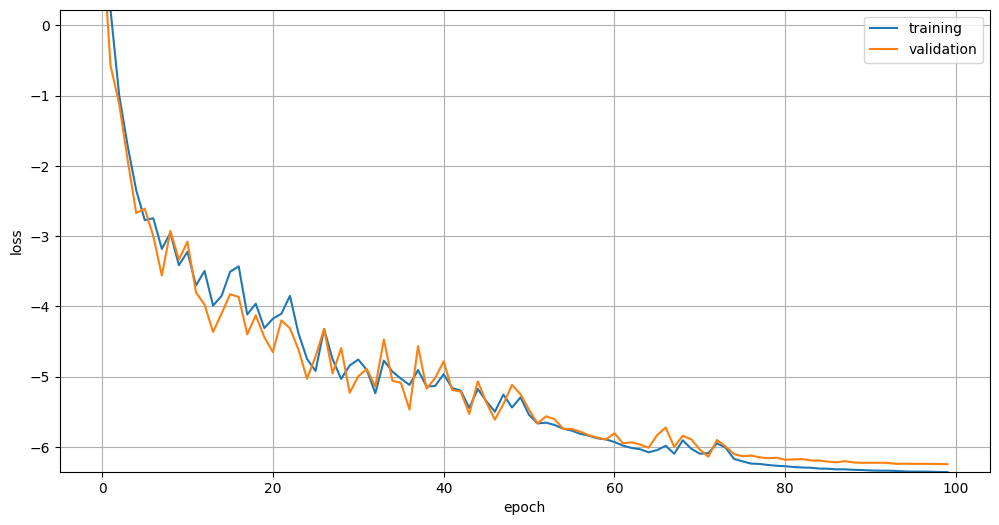

In [14]:
# default to train from scratch with 4 permutations per grid point
model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    # dataset
    batch_size=10_000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-3,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    scheduler_kwargs={"eta_min": 1e-5},
    # early stopping
    n_patience_epochs=None,
    min_delta=1e-5,
    save_model=True,
)

In [15]:
# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-3,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [16]:
# # default to train from scratch with 4 permutations per grid point
# model.fit(
#     x=grid_preds,
#     theta=grid_cosmos,
#     n_epochs=100,
#     # dataset
#     batch_size=10_000,
#     vali_split=0.1,
#     # optimizer
#     learning_rate=1e-2,
#     weight_decay=0.0,
#     clip_by_global_norm=1.0,
#     # scheduler
#     scheduler_type="cosine",
#     scheduler_kwargs={"eta_min": 1e-5},
#     # early stopping
#     n_patience_epochs=None,
#     min_delta=1e-5,
#     save_model=True,
# )

In [17]:
# grid_preds_sample = model.plot_diagnostics(
#     # these must be the raw arrays where the cosmo and example axis are still separate
#     grid_preds_true=grid_preds,
#     grid_cosmos=grid_cosmos,
#     n_samples=100,
#     # do_hist=True,
#     do_dlss=True,
#     do_eecp=True,
#     do_tarp=True,
# )

# observation

### CosmoGrid

In [18]:
# i_obs = 0
# # i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
# print(f"Using the example index {i_obs}")

# obs_pred = fidu_preds[i_obs]

# obs_point = {str(param): value for param, value in zip(params, parameters.get_fiducials(params))}
# obs_label = f"fiducial_{i_obs}_{loss}"

# print(obs_pred)

In [19]:
# obs_pred = np.mean(fidu_preds, axis=0)
# obs_point = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))}
# obs_label = f"fiducial_mean"

# print(obs_pred)

In [20]:
# obs_pred = grid_preds[0]
# obs_point = {str(param): value for param, value in zip(params, parameters.get_fiducials(params))}
# # obs_point = None
# obs_label = f"grid_0"

# print(obs_pred)

In [21]:
# i_example = 100

# obs_pred = grid_preds[i_example]
# obs_point = {str(param): value for param, value in zip(params, grid_cosmos[i_example])}
# obs_label = f"grid_{i_example}"

# print(obs_point)
# print(obs_pred)

### external

In [22]:
# obs_label = f"Buzzard"
# obs_pred = np.squeeze(buzzard_pred)
# obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan}

# # obs_label = f"Cardinal"
# # obs_pred = np.squeeze(cardinal_pred)
# # obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan}

# # obs_label = f"MICE"
# # obs_pred = np.squeeze(mice_pred)
# # obs_point = {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan}

# print(obs_pred)

### MCMC

In [23]:
# posterior_samples = model.sample_posterior(
#     obs_pred,
#     label=obs_label,
# )

### plotting

In [24]:
# model.plot_contours(
#     posterior_samples,
#     obs_point=obs_point,
#     obs_label=obs_label,
#     label=obs_label,
#     with_des_chain=False,
# )

# multiple observations

In [25]:
# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# buzzard_flock_preds = []
# with h5py.File(pred_file, "r") as f:
#     for buzzard_flock_label in buzzard_flock_labels:
#         buzzard_flock_preds.append(np.squeeze(try_mock(f, buzzard_flock_label)))
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
# buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)


Starting with mock observation fiducial_0
[ 0.57290816  0.07150802  0.03250945 -0.45941922  0.49966726  0.50096846]
24-10-11 06:22:20      mcmc.py INF   Initial values in prior: False 
24-10-11 06:22:20      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-10-11 06:22:23      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:11<00:00, 44.02it/s]

24-10-11 06:22:34      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,cosine=False,steps=100000/16mpc/likelihood_flow/chain_fiducial_0.npy 


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

100%|██████████| 500/500 [00:11<00:00, 43.14it/s]

24-10-11 06:22:53      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,cosine=False,steps=100000/16mpc/likelihood_flow/chain_fiducial_mean.npy 


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-10-11 06:22:57  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/run_files/v11/cls/lensing=True,clustering=False,standard=False,cosine=False,steps=100000/16mpc/likelihood_flow/contours_fiducial_mean.png 


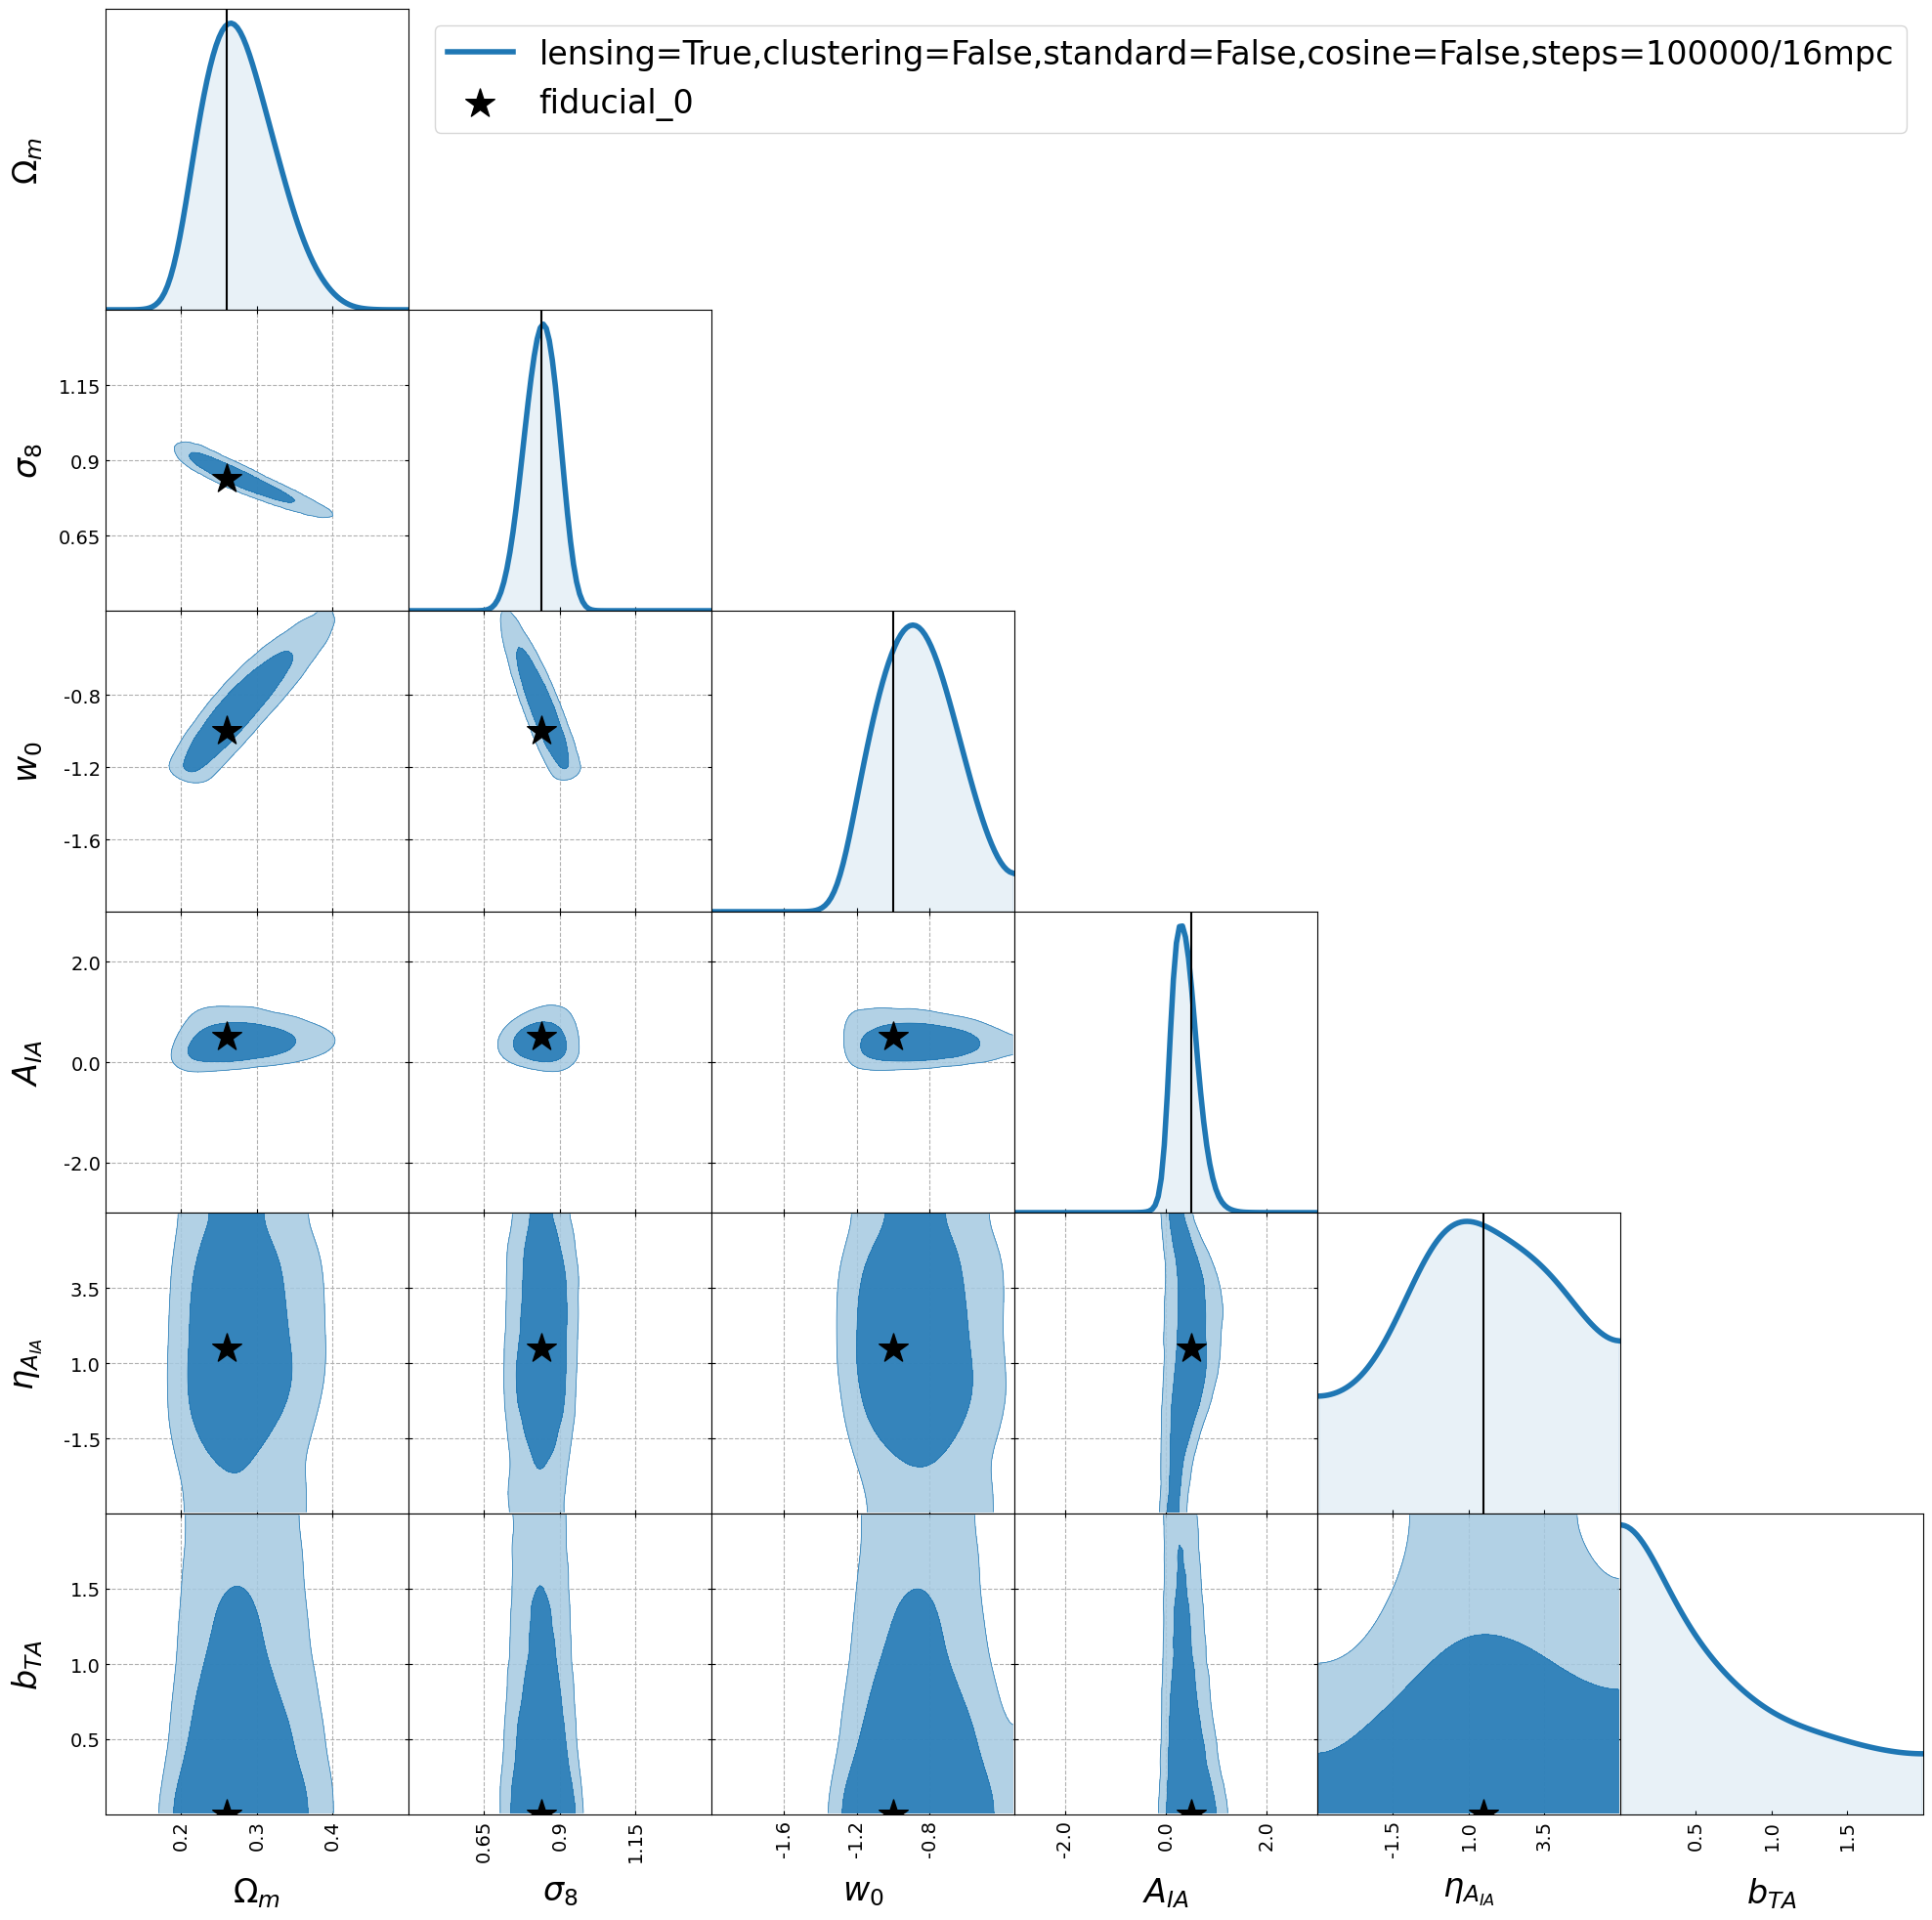

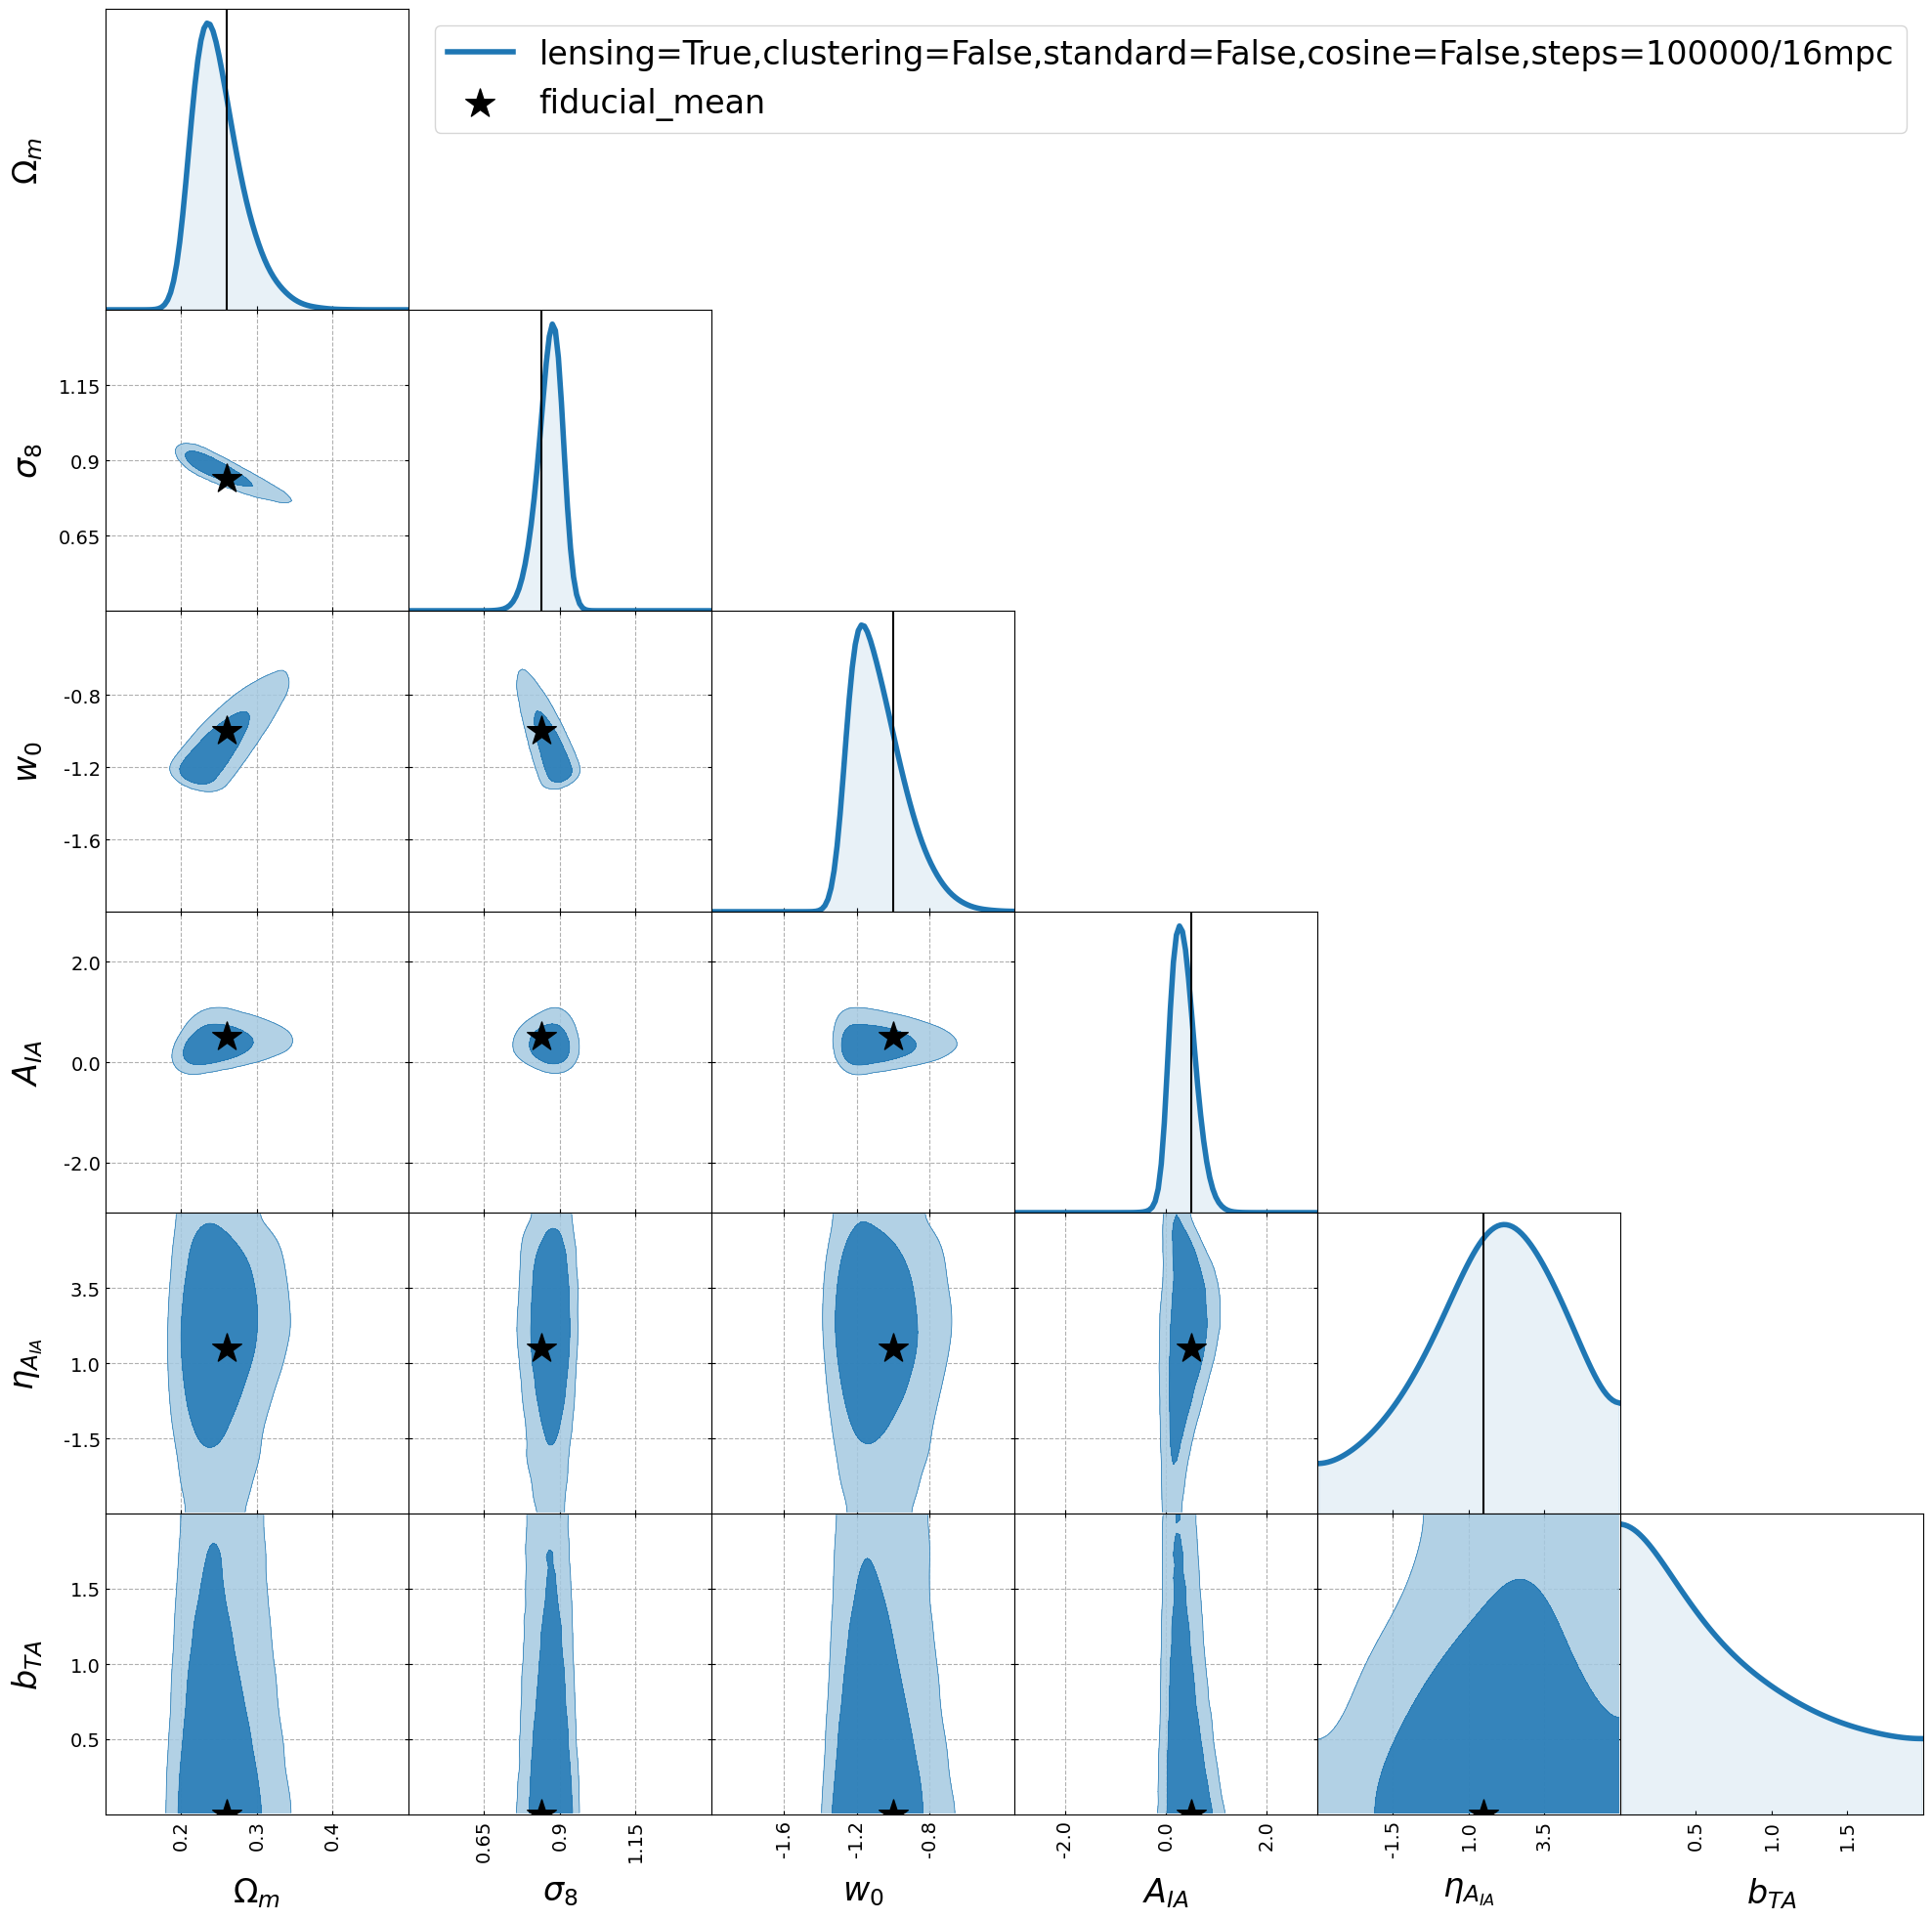

In [26]:
i_fidu = 0
i_grid = 100

obs_dict = {
    f"fiducial_{i_fidu}": {
        "pred": fidu_preds[i_fidu], 
        "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
    },
    f"fiducial_mean": {
        "pred": np.mean(fidu_preds, axis=0),
        "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
    },
    # f"grid_{i_grid}": {
    #     "pred": grid_preds[i_grid],
    #     "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
    # },
    # f"Buzzard": {
    #     "pred": np.squeeze(buzzard_pred),
    #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
    #     # "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
    # },
    # f"Buzzard_mean": {
    #     "pred": np.squeeze(buzzard_flock_mean),
    #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
    #     # "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
    # },
    # f"Cardinal": {
    #     "pred": np.squeeze(cardinal_pred),
    #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
    #     # "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
    # },
    # f"MICE": {
    #     "pred": np.squeeze(mice_pred),
    #     "point": {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
    # },
    # f"Euclid": {
    #     "pred": np.squeeze(euclid_pred),
    #     "point": {"Om": 0.319, "s8": 0.83, "w0": -1, "bg": np.nan, "n_bg": np.nan},
    # },
    # f"Buzzard_mocked_DNF": {
    #     "pred": np.squeeze(buzzard_pred_dnf),
    #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
    # },
}

# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# with h5py.File(pred_file, "r") as f:
#     for buzzard_flock_label in buzzard_flock_labels:
#         obs_dict[buzzard_flock_label] = {
#             "pred": np.squeeze(try_mock(f, buzzard_flock_label)),
#             "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#         }

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    
    print(obs_dict[key]["pred"])
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key,
    )

    model.plot_contours(
        posterior_samples,
        obs_point=obs_dict[key]["point"],
        obs_label=key,
        label=key,
        with_des_chain=False,
    )

In [27]:
# buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# buzzard_flock_preds = []
# with h5py.File(pred_file, "r") as f:
#     for buzzard_flock_label in buzzard_flock_labels:
#         buzzard_flock_preds.append(np.squeeze(try_mock(f, buzzard_flock_label)))
# buzzard_flock_preds = np.stack(buzzard_flock_preds, axis=0)
# buzzard_flock_mean = np.mean(buzzard_flock_preds, axis=0)
                
# posterior_samples = model.sample_posterior(
#     buzzard_flock_mean,
#     label="Buzzard_mean",
# )

# model.plot_contours(
#     posterior_samples,
#     obs_point={"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     obs_label="Buzzard_mean",
#     label="Buzzard_mean",
#     with_des_chain=False,
# )

# trash

In [28]:
# i_fidu = 0
# i_grid = 100

# obs_dict = {
#     # f"fiducial_{i_fidu}": {
#     #     "pred": fidu_preds[i_fidu], 
#     #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
#     # },
#     # f"fiducial_mean": {
#     #     "pred": np.mean(fidu_preds, axis=0),
#     #     "point": {str(param): value for param, value in zip(params, parameters.get_fiducials(params, conf))},
#     # },
#     f"grid_{i_grid}": {
#         "pred": grid_preds[i_grid],
#         "point": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
#     },
#     # f"Buzzard": {
#     #     "pred": np.squeeze(buzzard_pred),
#     #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#     #     # "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     # },
#     # f"Buzzard_mean": {
#     #     "pred": np.squeeze(buzzard_flock_mean),
#     #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#     #     # "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     # },
#     # f"Cardinal": {
#     #     "pred": np.squeeze(cardinal_pred),
#     #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg1": np.nan, "bg2": np.nan, "bg3": np.nan, "bg4": np.nan},
#     #     # "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     # },
#     # f"MICE": {
#     #     "pred": np.squeeze(mice_pred),
#     #     "point": {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     # },
#     # f"Euclid": {
#     #     "pred": np.squeeze(euclid_pred),
#     #     "point": {"Om": 0.319, "s8": 0.83, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     # },
#     # f"Buzzard_mocked_DNF": {
#     #     "pred": np.squeeze(buzzard_pred_dnf),
#     #     "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     # },
# }

# # buzzard_flock_dir = "/global/u2/a/athomsen/multiprobe-simulation-forward-model/data/mock_observations/Buzzard_flock"
# # buzzard_flock_labels = os.listdir(buzzard_flock_dir)
# # buzzard_flock_labels = [file[23:-3] for file in buzzard_flock_labels]

# # with h5py.File(pred_file, "r") as f:
# #     for buzzard_flock_label in buzzard_flock_labels:
# #         obs_dict[buzzard_flock_label] = {
# #             "pred": np.squeeze(try_mock(f, buzzard_flock_label)),
# #             "point": {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# #         }

# for key in obs_dict.keys():
#     print(f"\nStarting with mock observation {key}")
    
#     print(obs_dict[key]["pred"])
#     posterior_samples = model.sample_posterior(
#         obs_dict[key]["pred"],
#         label=key,
#     )

#     model.plot_contours(
#         posterior_samples,
#         obs_point=obs_dict[key]["point"],
#         obs_label=key,
#         label=key,
#         with_des_chain=False,
#     )

In [29]:
# for label in obs_dict.keys():
#     print(label)

In [30]:
# i_fidu = 0
# i_grid = 0

# obs_preds = [
#     fidu_preds[i_fidu],
#     np.mean(fidu_preds, axis=0),
#     grid_preds[i_grid],
# ]

# obs_points = [
#     {str(param): value for param, value in zip(params, parameters.get_fiducials(params))},
#     {str(param): value for param, value in zip(params, parameters.get_fiducials(params))},
#     {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
#     {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan},
#     {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan},
# ]

# obs_labels = [
#     f"fiducial_{i_fidu}",
#     f"fiducial_mean",
#     f"grid_{i_grid}",
#     f"Buzzard",
#     f"Cardinal",
#     f"MICE",
    
# ]

# # obs_label = f"Buzzard"
# # obs_pred = np.squeeze(buzzard_pred)
# # obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan}

# # # obs_label = f"Cardinal"
# # # obs_pred = np.squeeze(cardinal_pred)
# # # obs_point = {"Om": 0.286, "s8": 0.82, "w0": -1, "bg": np.nan, "n_bg": np.nan}

# # # obs_label = f"MICE"
# # # obs_pred = np.squeeze(mice_pred)
# # # obs_point = {"Om": 0.25, "s8": 0.8, "w0": -1, "bg": np.nan, "n_bg": np.nan}


In [31]:
# posterior_samples = model.sample_posterior(
#     obs_pred,
#     label=obs_label,
# )

# model.plot_contours(
#     posterior_samples,
#     obs_point=obs_point,
#     obs_label=obs_label,
#     label=obs_label,
#     with_des_chain=False,
# )